In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [3]:
img = cv2.imread('../media\\Textoverlapimage.jpeg')

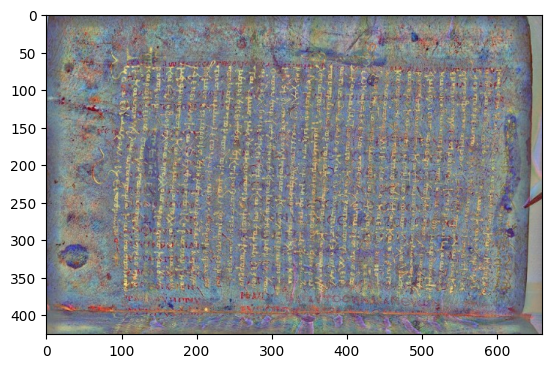

In [4]:
plt.imshow(img)

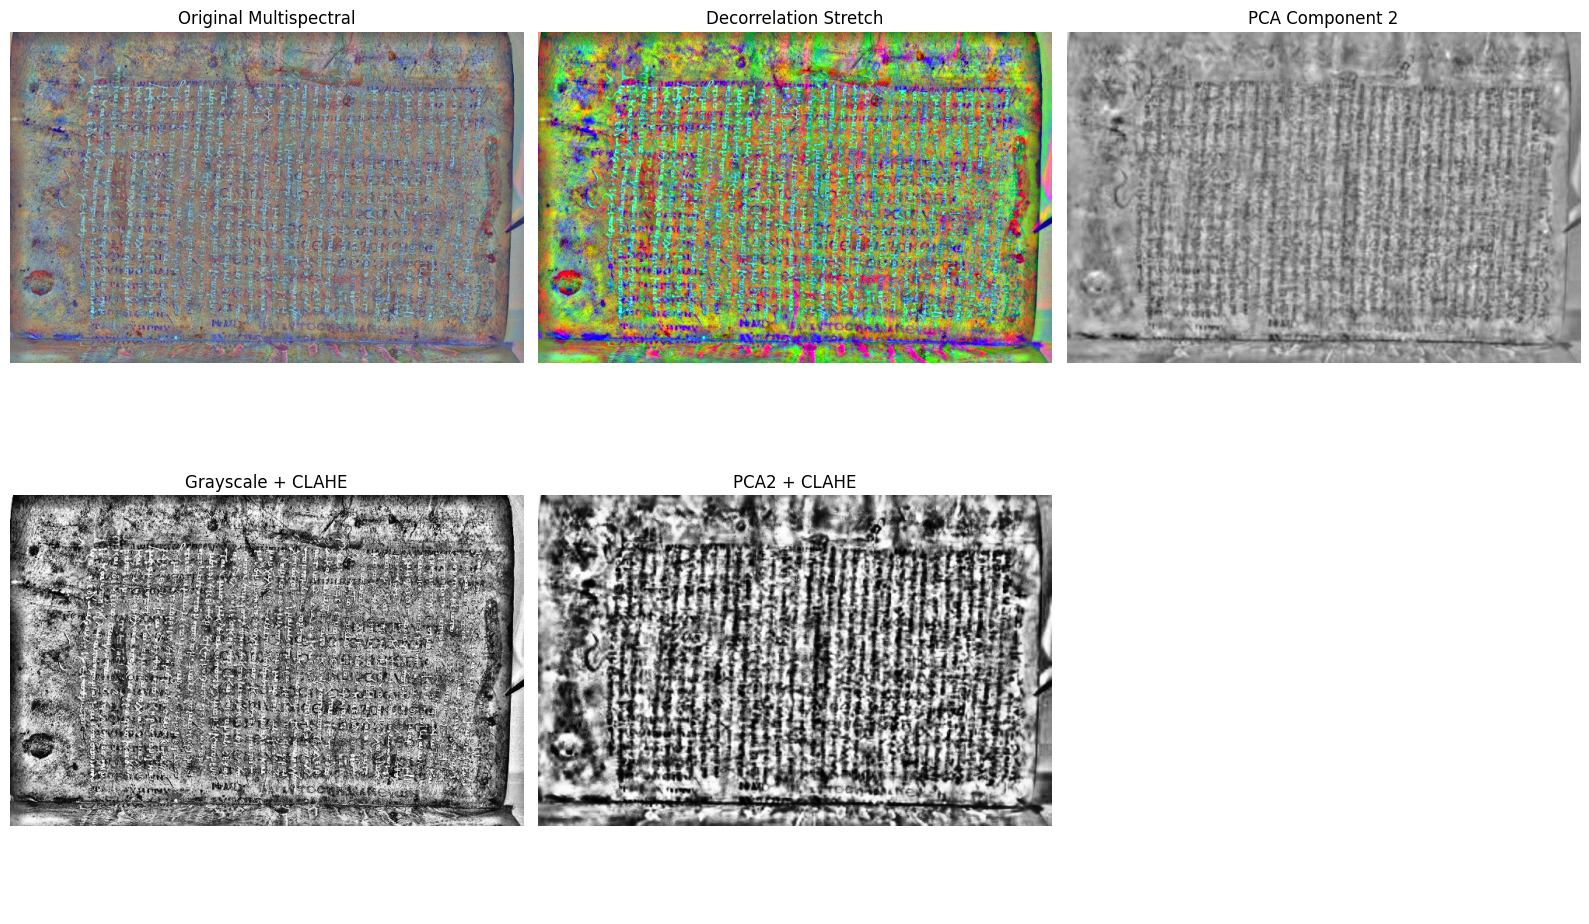

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def decorrelation_stretch(img):
    """
    Applies Decorrelation Stretch to boost subtle color differences 
    between faded ink and background.
    """
    orig_shape = img.shape
    pixels = img.reshape(-1, 3).astype(np.float64)

    mean = np.mean(pixels, axis=0)
    pixels_centered = pixels - mean
    cov = np.cov(pixels_centered, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(cov)

    stretch = np.diag(1.0 / np.sqrt(eigvals + 1e-5))
    transform = eigvecs @ stretch @ eigvecs.T
    stretched = pixels_centered @ transform

    for i in range(3):
        min_v, max_v = np.percentile(stretched[:, i], (1, 99))
        stretched[:, i] = np.clip(
            (stretched[:, i] - min_v) / (max_v - min_v + 1e-5) * 255, 0, 255
        )

    return stretched.reshape(orig_shape).astype(np.uint8)


def extract_pca_components(img):
    """
    Decomposes the image color channels into Principal Components.
    """
    h, w, c = img.shape
    pixels = img.reshape(-1, c)

    pca = PCA(n_components=c)
    pca_pixels = pca.fit_transform(pixels)

    components = []
    for i in range(c):
        comp = pca_pixels[:, i].reshape(h, w)
        comp_norm = cv2.normalize(comp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        components.append(comp_norm)

    return components


def enhance_local_contrast(gray_img, clip_limit=3.0, tile_size=(8, 8)):
    """
    Applies Contrast Limited Adaptive Histogram Equalization (CLAHE).
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(gray_img)


# --- MAIN EXECUTION ---
if __name__ == "__main__":
    img_path = '../media\\Textoverlapimage.jpeg'
    img = cv2.imread(img_path)

    if img is None:
        raise FileNotFoundError(f"Could not load image at {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Decorrelation Stretch
    dstretch = decorrelation_stretch(img_rgb)

    # 2. PCA Component Extraction
    pca_comps = extract_pca_components(img_rgb)

    # 3. Local Contrast Enhancement
    clahe_gray = enhance_local_contrast(gray, clip_limit=4.0)
    clahe_pca2 = enhance_local_contrast(pca_comps[1], clip_limit=4.0)

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Original Multispectral")

    axes[0, 1].imshow(dstretch)
    axes[0, 1].set_title("Decorrelation Stretch")

    axes[0, 2].imshow(pca_comps[1], cmap='gray')
    axes[0, 2].set_title("PCA Component 2")

    axes[1, 0].imshow(clahe_gray, cmap='gray')
    axes[1, 0].set_title("Grayscale + CLAHE")

    axes[1, 1].imshow(clahe_pca2, cmap='gray')
    axes[1, 1].set_title("PCA2 + CLAHE")

    axes[1, 2].axis('off')  # placeholder for removed Sauvola panel

    for ax in axes.ravel():
        ax.axis('off')

    plt.tight_layout()
    plt.show()



In [13]:
cv2.imshow("Grayscale + CLAHE", clahe_gray)
cv2.waitKey(0)
cv2.destroyAllWindows()

Yen threshold value: 131


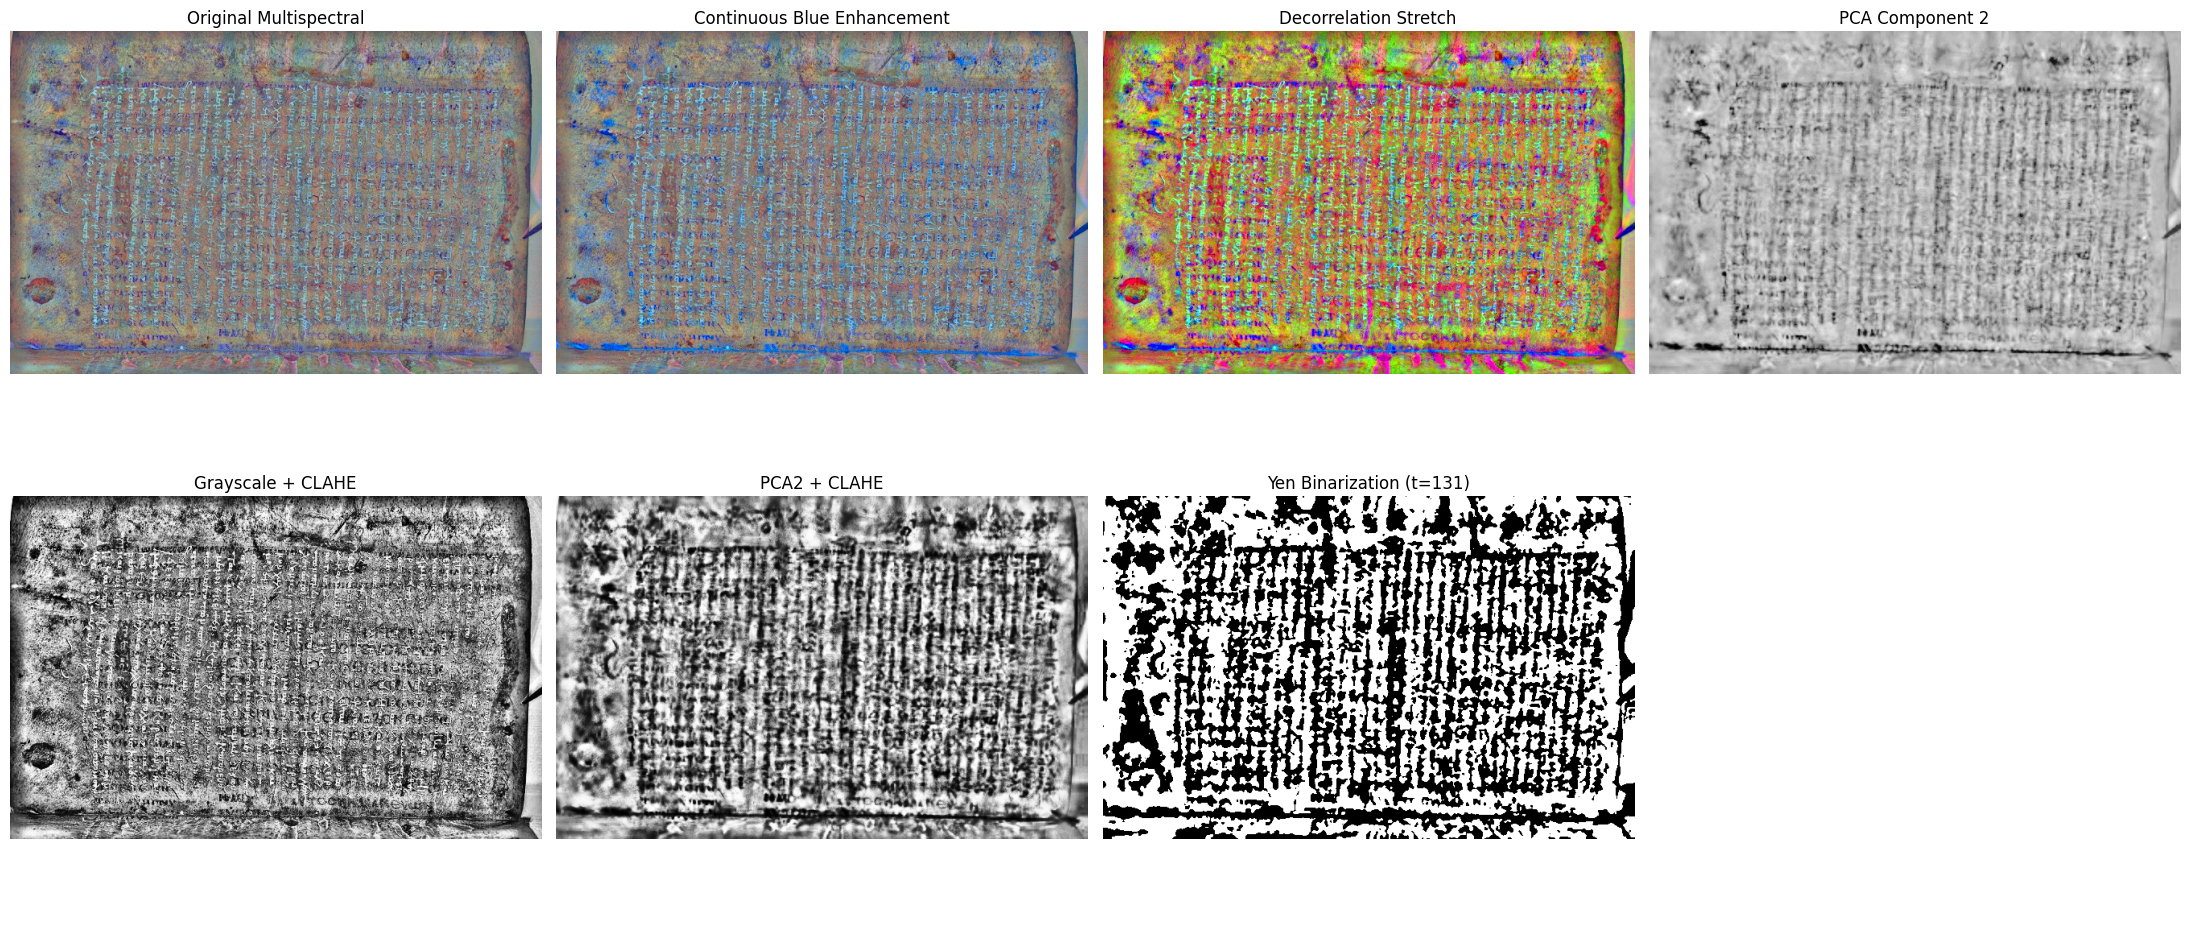

In [17]:
def decorrelation_stretch(img):
    """
    Applies Decorrelation Stretch to boost subtle color differences 
    between faded ink and background.
    """
    orig_shape = img.shape
    pixels = img.reshape(-1, 3).astype(np.float64)

    mean = np.mean(pixels, axis=0)
    pixels_centered = pixels - mean
    cov = np.cov(pixels_centered, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(cov)

    stretch = np.diag(1.0 / np.sqrt(eigvals + 1e-5))
    transform = eigvecs @ stretch @ eigvecs.T
    stretched = pixels_centered @ transform

    for i in range(3):
        min_v, max_v = np.percentile(stretched[:, i], (1, 99))
        stretched[:, i] = np.clip(
            (stretched[:, i] - min_v) / (max_v - min_v + 1e-5) * 255, 0, 255
        )

    return stretched.reshape(orig_shape).astype(np.uint8)


def continuous_blue_enhancement(img_rgb, strength=1.8):
    """
    Continuously enhances the blue information of an RGB image.

    Strategy:
      1. Convert to LAB (perceptually uniform) and isolate the blue/yellow
         opponent axis (b* channel: low = blue, high = yellow).
      2. Push pixels whose b* value is on the blue side (b* < 128) further
         toward blue using a continuous gain — no hard thresholds.
      3. Recombine back to RGB.

    'strength' controls the gain. 1.0 = no change, 1.5-2.5 = typical useful
    range for faded blue ink on parchment.
    """
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = cv2.split(lab)   # B here is the b* channel (0-255 in OpenCV 8-bit)

    # Distance from neutral (128) toward blue (below 128) is the "blueness"
    blueness = np.clip(128.0 - B, 0.0, 128.0) / 128.0   # 0..1

    # Continuous, smoothly-weighted push away from neutral, toward blue
    B_enhanced = B - (strength - 1.0) * blueness * 128.0
    B_enhanced = np.clip(B_enhanced, 0, 255)

    lab_out = cv2.merge([L, A, B_enhanced]).astype(np.uint8)
    enhanced_rgb = cv2.cvtColor(lab_out, cv2.COLOR_LAB2RGB)
    return enhanced_rgb


def extract_pca_components(img):
    """
    Decomposes the image color channels into Principal Components.
    """
    h, w, c = img.shape
    pixels = img.reshape(-1, c)

    pca = PCA(n_components=c)
    pca_pixels = pca.fit_transform(pixels)

    components = []
    for i in range(c):
        comp = pca_pixels[:, i].reshape(h, w)
        comp_norm = cv2.normalize(comp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        components.append(comp_norm)

    return components


def enhance_local_contrast(gray_img, clip_limit=3.0, tile_size=(8, 8)):
    """
    Applies Contrast Limited Adaptive Histogram Equalization (CLAHE).
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    return clahe.apply(gray_img)


def yen_threshold_value(gray_img):
    """
    Computes Yen's threshold using only NumPy.
    """
    hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256]).ravel()
    p = hist / hist.sum()

    eps = 1e-12
    P1 = np.cumsum(p)
    P2 = 1.0 - P1

    levels = np.arange(256, dtype=np.float64)
    cum_mean = np.cumsum(p * levels)
    mu1 = cum_mean / (P1 + eps)
    mu2 = (cum_mean[-1] - cum_mean) / (P2 + eps)

    cum_sq_mean = np.cumsum(p * levels * levels)
    var1 = np.clip(cum_sq_mean / (P1 + eps) - mu1 * mu1, 0, None)
    var2 = np.clip((cum_sq_mean[-1] - cum_sq_mean) / (P2 + eps) - mu2 * mu2, 0, None)

    numerator = P1 * P2 * (mu1 - mu2) ** 2
    denominator = P1 * var1 + P2 * var2 + eps
    criterion = numerator / denominator

    criterion[0] = 0
    criterion[-1] = 0

    return int(np.argmax(criterion))


def binarize_yen(gray_img):
    blurred = cv2.GaussianBlur(gray_img, (3, 3), 0)
    t = yen_threshold_value(blurred)
    _, binary = cv2.threshold(blurred, t, 255, cv2.THRESH_BINARY)
    return binary, t


# --- MAIN EXECUTION ---
if __name__ == "__main__":
    img_path = '../media\\Textoverlapimage.jpeg'
    img = cv2.imread(img_path)

    if img is None:
        raise FileNotFoundError(f"Could not load image at {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 1. Continuous Blue Enhancement (do this FIRST on the raw RGB image)
    blue_enhanced = continuous_blue_enhancement(img_rgb, strength=1.8)

    # 2. Decorrelation Stretch (on the blue-enhanced image)
    dstretch = decorrelation_stretch(blue_enhanced)

    # 3. PCA Component Extraction (on the blue-enhanced image)
    pca_comps = extract_pca_components(blue_enhanced)

    # 4. Local Contrast Enhancement
    clahe_gray = enhance_local_contrast(gray, clip_limit=4.0)
    clahe_pca2 = enhance_local_contrast(pca_comps[1], clip_limit=4.0)

    # 5. Yen Binarization on CLAHE-enhanced PCA2
    yen_binary, yen_t = binarize_yen(clahe_pca2)
    print(f"Yen threshold value: {yen_t}")

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title("Original Multispectral")

    axes[0, 1].imshow(blue_enhanced)
    axes[0, 1].set_title("Continuous Blue Enhancement")

    axes[0, 2].imshow(dstretch)
    axes[0, 2].set_title("Decorrelation Stretch")

    axes[0, 3].imshow(pca_comps[1], cmap='gray')
    axes[0, 3].set_title("PCA Component 2")

    axes[1, 0].imshow(clahe_gray, cmap='gray')
    axes[1, 0].set_title("Grayscale + CLAHE")

    axes[1, 1].imshow(clahe_pca2, cmap='gray')
    axes[1, 1].set_title("PCA2 + CLAHE")

    axes[1, 2].imshow(yen_binary, cmap='gray')
    axes[1, 2].set_title(f"Yen Binarization (t={yen_t})")

    axes[1, 3].axis('off')

    for ax in axes.ravel():
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
cv2.imshow("Yen Binarization", blue_enhanced)
cv2.waitKey(0)
cv2.destroyAllWindows()